# AdaBoost Classifier

> Weak learners : Ml algo whose accuracy is just above 50% are considered as Weak while ml algo's with accuracy nearly 95% or above are considered Strong

> Decision Stumps : This is a type of Weak learners which contains a DT whose max depth is 1 means split on single node

> Classificatn pts are +1 and -1 not 1 or 0

- AdaBoost is a Stagewise Additive Method(combinatn of Weak learners) where we do only One split or make 1 Decision Stumps in such a way that give least reductn in entropy

<img src='img1.png'></img>

> AdaBoost Step by step

- Firstly we choose a DS which have least entropy 
- Then we assign intial weight to all rows as 1/n.
- Then we find pred using that model
- After that we assign weight based on their error rate
- If error is low -> High weight and if error is high -> weight is low

- Formula for weight or alpha:  
    alpha = 1/2*ln((1-error) / error)

- Error : sum of weights of those rows which are mis-classified 

<img src='img2.png'></img>

- Now by using this formula, we calculate first Decision Stump weight(which tell what weight it will give in result)

Now after that this info passes to next DS by increasing weight of mis-classified pts and reducing weights of right classified pts using formula's

<img src='img3.png'></img>

Now after getting updated weight, calculate sum of updated wt and divide all wt's by sum to get normalised wt whose sum will be 1

<img src='img4.png'></img>

Now we do Upsampling where we find define range by adding weight as shown in figure and the rows which are mis-classified will have large range -> so there prob of picking is high when we select random pts

So when we selct random pts and the range in which they fall -> those rows will be the dataset for next DS

<img src='img5.png'></img>

Now this dataset will pass to next DS and the same prcess will be repeated where new alpha will find and behaviour of DS will also chnage as dataset is changed

In [51]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [52]:
df = pd.DataFrame()

In [53]:
df['x1'] = [1,2,3,4,5,6,6,7,9,9]
df['x2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [54]:
df

,x1,x2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='x1', ylabel='x2'>

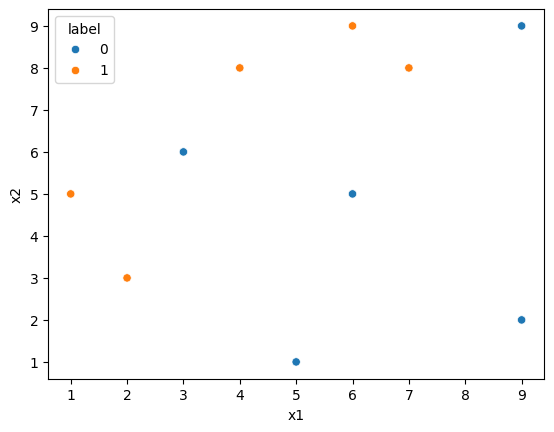

In [55]:
import seaborn as sns
sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['label'])

In [56]:
# Step 1 : Assigning initial wts
df['weights'] = 1 / df.shape[0]

In [57]:
df

,x1,x2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [58]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(max_depth=1)

In [59]:
x = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [60]:
# Step 2 : Train 1st model
dt1.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

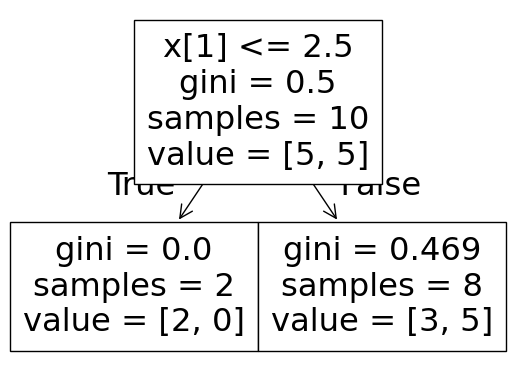

In [61]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

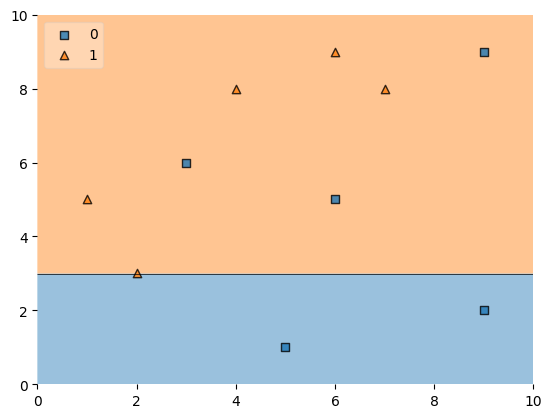

In [62]:
plot_decision_regions(x,y, clf=dt1, legend=2)

In [63]:
df['y_pred'] = dt1.predict(x)

In [42]:
df

,x1,x2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [64]:
def calculate_model_wt(error):
    return 0.5 * np.log((1-error)/(error))

In [65]:
# Step 3 : calculate first model wt
alpha1 = calculate_model_wt(0.3)
alpha1

np.float64(0.42364893019360184)

- Here we multiply mis-classified pts with higher alpha values to increase the wts of mis-classified pts

- As we want to increase wt of misclassified pts so we need to multiply them with big no -> so multiply with higher alpha val(means more accurate pred) -> so we multiply miscalssified rows with e^(+alpha)

- Whereas correctly classified row is multiplied with e^(-alpha) to reduce its wts values

In [66]:
# Step 4 : Update wts
def update_row_wts(row, alpha=0.423):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [67]:
df['updated_wts'] = df.apply(update_row_wts, axis=1)

In [68]:
df

,x1,x2,label,weights,y_pred,updated_wts
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [69]:
df['updated_wts'].sum()

np.float64(0.9165153319682015)

In [70]:
# Step 5 : Normalising the wts
df['normalised_wts'] = df['updated_wts'] / df['updated_wts'].sum()

In [71]:
df

,x1,x2,label,weights,y_pred,updated_wts,normalised_wts
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [72]:
# Step 6 : Making ranges
df['cumsum_upper'] = np.cumulative_sum(df['normalised_wts'])

In [73]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalised_wts']

In [74]:
df[['x1','x2','label','weights','y_pred','updated_wts','cumsum_lower','cumsum_upper']]

,x1,x2,label,weights,y_pred,updated_wts,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


Step 7: Creating second df

In [75]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [76]:
index_values = create_new_dataset(df)

index_values

[2, 0, 4, 6, 4, 2, 9, 6, 2, 2]

In [77]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [78]:
second_df

,x1,x2,label,weights
2,3,6,0,0.1
0,1,5,1,0.1
4,5,1,0,0.1
6,6,5,0,0.1
4,5,1,0,0.1
2,3,6,0,0.1
9,9,2,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1
2,3,6,0,0.1


Step 8 : Creating 2 DS

In [79]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [80]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [81]:
dt2.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[0] <= 2.0\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.625, 0.5, '  False')]

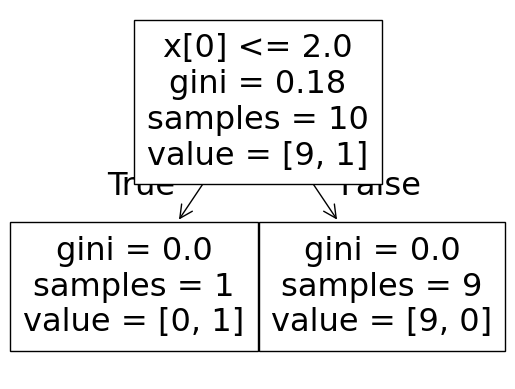

In [82]:
plot_tree(dt2)

<Axes: >

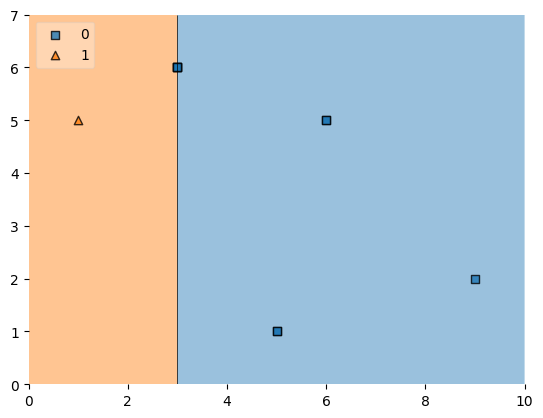

In [83]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [84]:
second_df['y_pred'] = dt2.predict(X)

In [85]:
second_df

,x1,x2,label,weights,y_pred
2,3,6,0,0.1,0
0,1,5,1,0.1,1
4,5,1,0,0.1,0
6,6,5,0,0.1,0
4,5,1,0,0.1,0
2,3,6,0,0.1,0
9,9,2,0,0.1,0
6,6,5,0,0.1,0
2,3,6,0,0.1,0
2,3,6,0,0.1,0


In [86]:
alpha2 = calculate_model_wt(0.1)

In [87]:
alpha2

np.float64(1.0986122886681098)

In [88]:
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [89]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [90]:
second_df

,x1,x2,label,weights,y_pred,updated_weights
2,3,6,0,0.1,0,0.033622
0,1,5,1,0.1,1,0.033622
4,5,1,0,0.1,0,0.033622
6,6,5,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622
2,3,6,0,0.1,0,0.033622
9,9,2,0,0.1,0,0.033622
6,6,5,0,0.1,0,0.033622
2,3,6,0,0.1,0,0.033622
2,3,6,0,0.1,0,0.033622


In [91]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [92]:
second_df

,x1,x2,label,weights,y_pred,updated_weights,nomalized_weights
2,3,6,0,0.1,0,0.033622,0.1
0,1,5,1,0.1,1,0.033622,0.1
4,5,1,0,0.1,0,0.033622,0.1
6,6,5,0,0.1,0,0.033622,0.1
4,5,1,0,0.1,0,0.033622,0.1
2,3,6,0,0.1,0,0.033622,0.1
9,9,2,0,0.1,0,0.033622,0.1
6,6,5,0,0.1,0,0.033622,0.1
2,3,6,0,0.1,0,0.033622,0.1
2,3,6,0,0.1,0,0.033622,0.1


In [93]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [95]:
second_df[['x1','x2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,x1,x2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
2,3,6,0,0.1,0,0.1,0.0,0.1
0,1,5,1,0.1,1,0.1,0.1,0.2
4,5,1,0,0.1,0,0.1,0.2,0.3
6,6,5,0,0.1,0,0.1,0.3,0.4
4,5,1,0,0.1,0,0.1,0.4,0.5
2,3,6,0,0.1,0,0.1,0.5,0.6
9,9,2,0,0.1,0,0.1,0.6,0.7
6,6,5,0,0.1,0,0.1,0.7,0.8
2,3,6,0,0.1,0,0.1,0.8,0.9
2,3,6,0,0.1,0,0.1,0.9,1.0


Step 9 : Creating 3rd df

In [96]:
index_values = create_new_dataset(second_df)

In [97]:
# Creating thrid dataset
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [98]:
third_df

,x1,x2,label,weights
4,5,1,0,0.1
2,3,6,0,0.1
4,5,1,0,0.1
2,3,6,0,0.1
4,5,1,0,0.1
4,5,1,0,0.1
4,5,1,0,0.1
4,5,1,0,0.1
2,3,6,0,0.1
4,5,1,0,0.1


In [99]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

<Axes: >

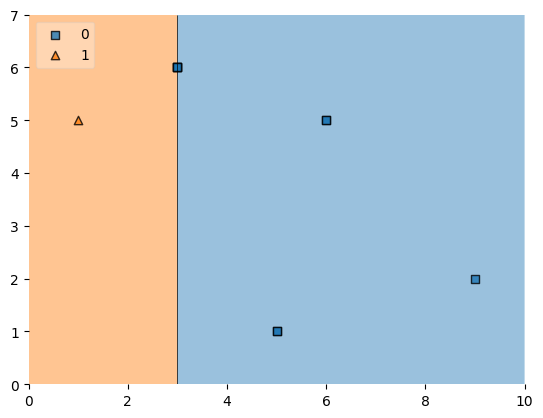

In [100]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [101]:
third_df['y_pred'] = dt3.predict(X)

In [102]:
alpha3 = calculate_model_wt(0.7)
alpha3

np.float64(-0.4236489301936017)

In [103]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


> Prediction

In [104]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [105]:
dt2.predict(query)

array([1])

In [106]:
dt3.predict(query)

array([1])

In [107]:
alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(1.09861228866811)

In [108]:
np.sign(1.09)

np.float64(1.0)

In [109]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([1])

In [110]:
dt2.predict(query)

array([0])

In [111]:
dt3.predict(query)

array([0])

In [112]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

np.float64(-0.2513144282809062)

In [113]:
np.sign(-0.25)

np.float64(-1.0)

# Bagging Vs Boosting
There are three techniques to reduce or convert LBHV to LBLV which are : Regularizatn, Bagging, Boosting 

> Types of models used

We use Bagging for LBHV models like Fully grown DT whereas We use Boosting for HBLV models such a Shallow DT or Decision Stumps

> Sequential Vs Parallel

In Bagging, we train all base models Parallely as we pass sample dataset to all models randomly whereas In Boosting, we train models sequentially one after other

> Weightage of base learners

In Bagging, weightage of all base models are same as test result count on majority bases whereas In Boosting, every model have diff weightage as better the model -> better the weightage in pred

ONE LIFE

WHY AREN'T WE RUNNING LIE WE ARE ON FIRED TOWARDS OUR WILDEST DREAMS

WE GOT ONE SHOT

WHY AREN'T WE LIE CRAZY ONE

I WANT PEOPLE LOO AT ME THAT GUY IS A NUTS

GOOD 

I GOT ONE SHOT AT THIS LIFE

CALL ME CRAZY OR DREAMER RATHER THAN SETTLER

I MADE NOT TO STAND IN LINE

I MADE TO STAND OUT